In [3]:
import pandas as pd
print("Working ✅")

Working ✅


In [4]:
!pip install seaborn

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
df = pd.read_csv(r"C:\product-demand-classification\data\online_retail.csv")

df.head()

,index,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [7]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   index        541909 non-null  int64  
 1   InvoiceNo    541909 non-null  object 
 2   StockCode    541909 non-null  object 
 3   Description  540455 non-null  object 
 4   Quantity     541909 non-null  int64  
 5   InvoiceDate  541909 non-null  object 
 6   UnitPrice    541909 non-null  float64
 7   CustomerID   406829 non-null  float64
 8   Country      541909 non-null  object 
dtypes: float64(2), int64(2), object(5)
memory usage: 37.2+ MB


,index,Quantity,UnitPrice,CustomerID
count,541909.000000,541909.000000,541909.000000,406829.000000
mean,270954.000000,9.552250,4.611114,15287.690570
std,156435.797851,218.081158,96.759853,1713.600303
min,0.000000,-80995.000000,-11062.060000,12346.000000
25%,135477.000000,1.000000,1.250000,13953.000000
50%,270954.000000,3.000000,2.080000,15152.000000
75%,406431.000000,10.000000,4.130000,16791.000000
max,541908.000000,80995.000000,38970.000000,18287.000000


In [8]:
df.dropna(subset=['Description'], inplace=True)

In [9]:
df = df[~df['InvoiceNo'].astype(str).str.startswith('C')]

In [10]:
df = df[df['Quantity'] > 0]

In [11]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

In [12]:
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']

In [13]:
product_data = df.groupby('StockCode').agg({
    'Quantity': 'sum',
    'InvoiceNo': 'count',
    'TotalPrice': 'sum'
}).reset_index()

In [14]:
product_data.columns = ['StockCode', 'TotalQuantity', 'Frequency', 'TotalSales']

In [15]:
product_data.head()

,StockCode,TotalQuantity,Frequency,TotalSales
0,10002,860,71,759.89
1,10080,325,23,119.09
2,10120,193,30,40.53
3,10123C,5,3,3.25
4,10124A,16,5,6.72


In [16]:
product_data = product_data[~product_data['StockCode'].astype(str).str.contains('C')]

In [17]:
threshold = product_data['TotalQuantity'].mean()

product_data['Demand'] = product_data['TotalQuantity'].apply(
    lambda x: 1 if x > threshold else 0
)

In [18]:
product_data.head()

,StockCode,TotalQuantity,Frequency,TotalSales,Demand
0,10002,860,71,759.89,0
1,10080,325,23,119.09,0
2,10120,193,30,40.53,0
4,10124A,16,5,6.72,0
5,10124G,17,4,7.14,0


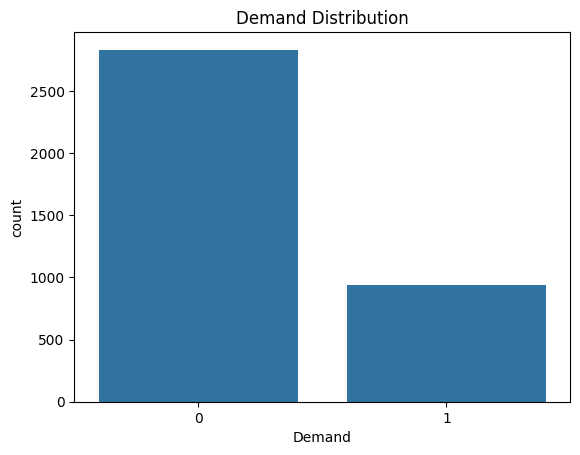

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='Demand', data=product_data)
plt.title("Demand Distribution")
plt.show()

In [20]:
!pip install scikit-learn

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [21]:
from sklearn.model_selection import train_test_split
print("Sklearn working ✅")

Sklearn working ✅


In [28]:
from sklearn.model_selection import train_test_split

X = product_data[['Frequency', 'TotalSales']]
y = product_data['Demand']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [29]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()
model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [30]:
y_pred = model.predict(X_test)

In [31]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Accuracy
print("Accuracy:", accuracy_score(y_test, y_pred))

# Confusion Matrix
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

# Classification Report
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.8794701986754967

Confusion Matrix:
 [[542  27]
 [ 64 122]]

Classification Report:
               precision    recall  f1-score   support

           0       0.89      0.95      0.92       569
           1       0.82      0.66      0.73       186

    accuracy                           0.88       755
   macro avg       0.86      0.80      0.83       755
weighted avg       0.88      0.88      0.87       755



In [34]:
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier(max_depth=5)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

In [35]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.871523178807947

Confusion Matrix:
 [[529  40]
 [ 57 129]]

Classification Report:
               precision    recall  f1-score   support

           0       0.90      0.93      0.92       569
           1       0.76      0.69      0.73       186

    accuracy                           0.87       755
   macro avg       0.83      0.81      0.82       755
weighted avg       0.87      0.87      0.87       755



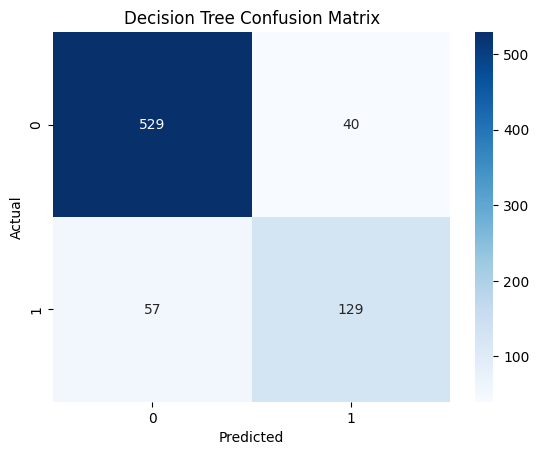

In [36]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Decision Tree Confusion Matrix")
plt.show()

In [37]:
import pandas as pd

importance = model.feature_importances_

for name, val in zip(X.columns, importance):
    print(f"{name}: {val}")

Frequency: 0.9619514883245074
TotalSales: 0.03804851167549263


In [38]:
print("Project Completed Successfully ✅")

Project Completed Successfully ✅
